# 1. Introducción

La luminosidad estelar ($L$) es una de las propiedades fundamentales en astrofísica, ya que determina la cantidad de energía que una estrella emite por unidad de tiempo. Comprender cómo la luminosidad depende de otras variables físicas, como la masa ($M$) y la temperatura superficial ($T$), es esencial para modelar la evolución estelar y caracterizar diferentes tipos de estrellas.

En la práctica, la relación entre $L$, $M$ y $T$ no es estrictamente lineal. Por ejemplo, la famosa relación de masa-luminosidad para estrellas de la secuencia principal es una ley de potencia, y la temperatura también influye de manera no lineal. Por ello, es necesario emplear modelos polinomiales que permitan capturar estas dependencias complejas.

En este cuaderno implementaremos **regresión polinomial multivariable** desde cero, utilizando únicamente **NumPy** y **Matplotlib**, siguiendo la metodología y estructura de los notebooks base del curso:
- Regresión lineal con una variable (sin y con vectorización)
- Vectorización y gradientes manuales
- Regresión multivariable y polinomial con ingeniería de características
El objetivo es construir un modelo que prediga la luminosidad estelar a partir de la masa y la temperatura, incorporando términos polinomiales e interacciones para mejorar la capacidad predictiva y la interpretación física.

A lo largo del cuaderno, derivaremos manualmente los gradientes, implementaremos el descenso por gradiente y analizaremos el impacto de cada término polinomial en el ajuste y la interpretación física del modelo.

# 2. Visualización del Dataset

A continuación se presenta el conjunto de datos utilizado en este estudio. Cada observación corresponde a una estrella, con su masa ($M$, en masas solares), temperatura superficial ($T$, en Kelvin) y luminosidad ($L$, en luminosidades solares).

Se graficará la luminosidad en función de la masa, codificando la temperatura mediante el color de los puntos para facilitar la interpretación física. Esto permite observar tendencias generales y posibles relaciones no lineales entre las variables.


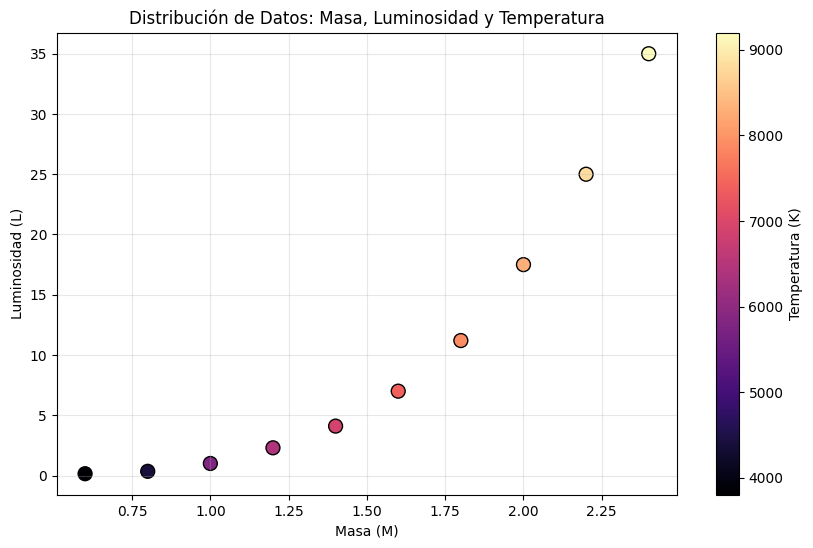

In [15]:
import numpy as np
import matplotlib.pyplot as plt

M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
T = np.array([3800, 4400, 5800, 6400, 6900, 7400, 7900, 8300, 8800, 9200])
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

plt.figure(figsize=(10, 6))
sc = plt.scatter(M, L, c=T, cmap='magma', s=100, edgecolors='k')
plt.colorbar(sc, label='Temperatura (K)')
plt.xlabel('Masa (M)')
plt.ylabel('Luminosidad (L)')
plt.title('Distribución de Datos: Masa, Luminosidad y Temperatura')
plt.grid(True, alpha=0.3)
plt.show()

**Interpretación física:**

- Se observa que la luminosidad crece rápidamente con la masa, lo que sugiere una relación no lineal.
- Las estrellas más masivas tienden a ser más calientes (mayor $T$) y mucho más luminosas.
- La codificación por color permite identificar que, a igual masa, una mayor temperatura suele asociarse a mayor luminosidad, aunque la dependencia principal es con la masa.

Esta visualización motiva el uso de modelos polinomiales e interacciones para capturar la complejidad de la relación entre $L$, $M$ y $T$.

# 3. Ingeniería de Características

Para capturar relaciones no lineales y de interacción entre las variables físicas, construiremos una **matriz de diseño** $X$ con las siguientes columnas:

- $M$: masa estelar
- $T$: temperatura superficial
- $M^2$: masa al cuadrado (término polinomial)
- $M \times T$: interacción entre masa y temperatura

Cada columna tiene una interpretación física:

- $M$: refleja la dependencia lineal directa de la luminosidad con la masa.
- $T$: permite capturar el efecto lineal de la temperatura.
- $M^2$: modela la relación no lineal (por ejemplo, la ley de masa-luminosidad es una potencia).
- $M \times T$: permite capturar efectos donde la influencia de la masa depende de la temperatura (interacción física).

In [17]:
def construir_X(M, T, incluir_M2=True, incluir_MT=True):
    """
    Construye la matriz de diseño X con las combinaciones deseadas.
    Args:
        M: array de masas
        T: array de temperaturas
        incluir_M2: si True, incluye M^2
        incluir_MT: si True, incluye M*T
    Returns:
        X: matriz de diseño (n_ejemplos, n_características)
    """
    columnas = [M, T]
    if incluir_M2:
        columnas.append(M**2)
    if incluir_MT:
        columnas.append(M*T)
    return np.column_stack(columnas)

X = construir_X(M, T, incluir_M2=True, incluir_MT=True)
print(f"Forma de la matriz X: {X.shape}")

Forma de la matriz X: (10, 4)


# 4. Función de Pérdida y Gradientes

El objetivo es ajustar los parámetros $w$ y $b$ del modelo lineal generalizado:

$$
\hat{L} = Xw + b
$$

donde $X$ es la matriz de diseño y $w$ el vector de pesos.

La función de pérdida utilizada es el **error cuadrático medio (MSE)**:

$$
J(w, b) = \frac{1}{2m} \sum_{i=1}^m (\hat{L}^{(i)} - L^{(i)})^2
$$

donde $m$ es el número de ejemplos.

## Gradientes manuales

Los gradientes respecto a $w$ y $b$ se derivan manualmente (ver notebooks base):

- Gradiente respecto a $w$:

$$
\nabla_w J(w, b) = \frac{1}{m} X^T (\hat{L} - L)
$$

- Gradiente respecto a $b$:

$$
\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^m (\hat{L}^{(i)} - L^{(i)})
$$

Estas expresiones permiten implementar el descenso por gradiente de forma vectorizada y eficiente.

In [18]:
def predecir(X, w, b):
    """Predicción lineal: L_hat = X @ w + b"""
    return X @ w + b

def calcular_costo(X, y, w, b):
    """Calcula el MSE: J(w, b) = (1/2m) * sum((L_hat - L)^2)"""
    m = X.shape[0]
    L_hat = predecir(X, w, b)
    error = L_hat - y
    return (error @ error) / (2 * m)

def calcular_gradientes(X, y, w, b):
    """Calcula los gradientes manuales de J respecto a w y b"""
    m = X.shape[0]
    L_hat = predecir(X, w, b)
    error = L_hat - y
    grad_w = (X.T @ error) / m
    grad_b = np.sum(error) / m
    return grad_w, grad_b

w_test = np.zeros(X.shape[1])
b_test = 0.0
print("MSE inicial:", calcular_costo(X, L, w_test, b_test))
gw, gb = calcular_gradientes(X, L, w_test, b_test)
print("Gradiente w inicial:", gw)
print("Gradiente b inicial:", gb)

MSE inicial: 117.69675
Gradiente w inicial: [-2.152300e+01 -8.784500e+04 -4.594340e+01 -1.854088e+05]
Gradiente b inicial: -10.36


# 5. Entrenamiento y Convergencia

Implementamos el algoritmo de **descenso por gradiente** para minimizar la función de pérdida y ajustar los parámetros del modelo. Se registra el historial de la pérdida para analizar la convergencia.

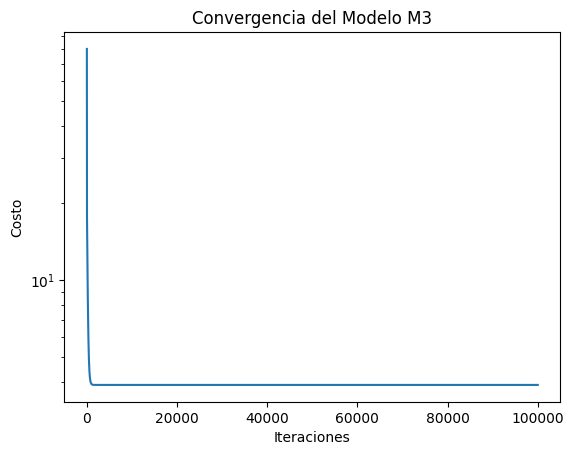

In [19]:
def descenso_gradiente(X, y, w_init, b_init, alpha, n_iter):
    """
    Descenso por gradiente para regresión lineal multivariable.
    Args:
        X: matriz de diseño
        y: vector objetivo
        w_init: pesos iniciales
        b_init: sesgo inicial
        alpha: tasa de aprendizaje
        n_iter: número de iteraciones
    Returns:
        w, b: parámetros finales
        hist_cost: historial de costo
    """
    w = w_init.copy()
    b = b_init
    hist_cost = []
    for i in range(n_iter):
        grad_w, grad_b = calcular_gradientes(X, y, w, b)
        w -= alpha * grad_w
        b -= alpha * grad_b
        hist_cost.append(calcular_costo(X, y, w, b))
    return w, b, hist_cost

w_ent, b_ent, hist_ent = descenso_gradiente(X, L, np.zeros(X.shape[1]), 0.0, 1e-9, 100000)

plt.plot(hist_ent)
plt.title('Convergencia del Modelo M3')
plt.xlabel('Iteraciones')
plt.ylabel('Costo')
plt.yscale('log')
plt.show()

# 6. Experimento de Selección de Características

Entrenaremos y compararemos tres modelos con diferentes conjuntos de características:

- **M1:** $[M, T]$
- **M2:** $[M, T, M^2]$
- **M3:** $[M, T, M^2, M \times T]$

Para cada modelo se reportará la pérdida final, los parámetros aprendidos y una gráfica de predicción vs valor real. Esto permitirá analizar el impacto de los términos polinomiales e interacción en el desempeño del modelo.

M1: [M, T] -> Pérdida Final: 41.1585


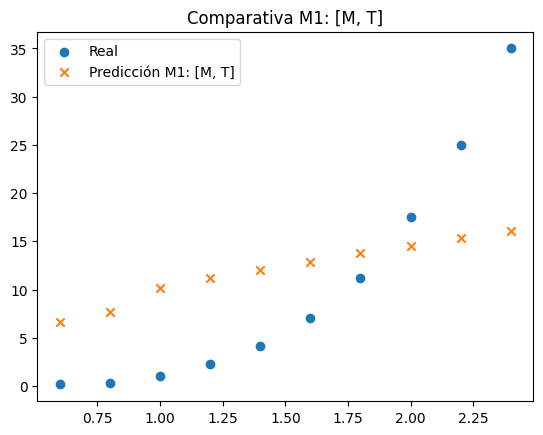

M2: [M, T, M^2] -> Pérdida Final: 41.1538


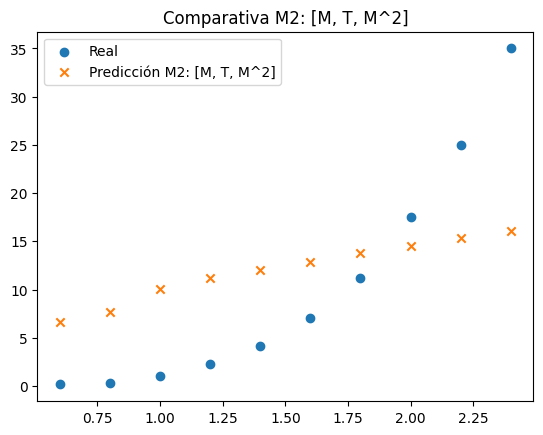

M3: [M, T, M^2, M*T] -> Pérdida Final: 3.8886


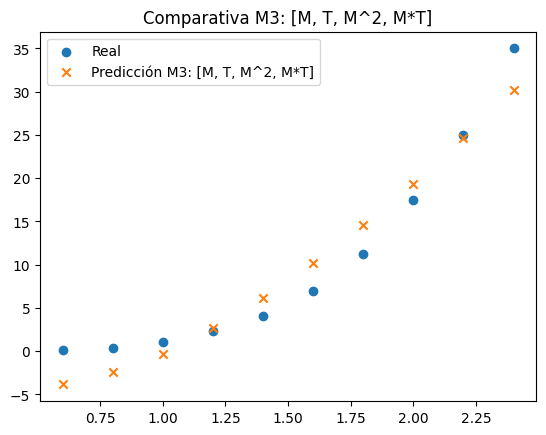

In [20]:
modelos = [
    {'nombre': 'M1: [M, T]', 'incluir_M2': False, 'incluir_MT': False, 'lr': 1e-8},
    {'nombre': 'M2: [M, T, M^2]', 'incluir_M2': True, 'incluir_MT': False, 'lr': 1e-9},
    {'nombre': 'M3: [M, T, M^2, M*T]', 'incluir_M2': True, 'incluir_MT': True, 'lr': 1e-9}
]

for modelo in modelos:
    X_mod = construir_X(M, T, incluir_M2=modelo['incluir_M2'], incluir_MT=modelo['incluir_MT'])
    w, b, hist = descenso_gradiente(X_mod, L, np.zeros(X_mod.shape[1]), 0.0, modelo['lr'], 100000)
    print(f"{modelo['nombre']} -> Pérdida Final: {hist[-1]:.4f}")
    pred = predecir(X_mod, w, b)
    plt.scatter(M, L, label='Real')
    plt.scatter(M, pred, label=f'Predicción {modelo["nombre"]}', marker='x')
    plt.title(f'Comparativa {modelo["nombre"]}')
    plt.legend()
    plt.show()

# 7. Costo vs Interacción

Para analizar la importancia física del término de interacción $M \times T$, fijamos los parámetros aprendidos del modelo M3 y variamos únicamente el peso $w_{MT}$ en un rango razonable. Calculamos el costo para cada valor y graficamos la curva resultante. Esto permite visualizar la sensibilidad del modelo a la interacción y su impacto en el ajuste.

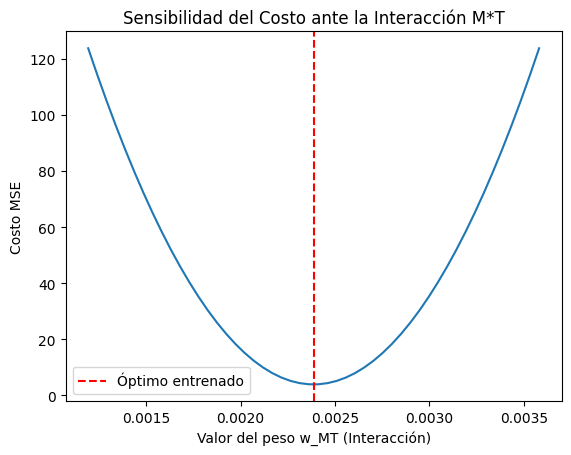

In [21]:
X_M3 = construir_X(M, T, incluir_M2=True, incluir_MT=True)
idx_MT = 3 
w_fijo = w_ent.copy()
b_fijo = b_ent

rango_MT = np.linspace(w_ent[idx_MT]*0.5, w_ent[idx_MT]*1.5, 50)
costos = []
for w_MT in rango_MT:
    w_temp = w_fijo.copy()
    w_temp[idx_MT] = w_MT
    costos.append(calcular_costo(X_M3, L, w_temp, b_fijo))

plt.plot(rango_MT, costos)
plt.axvline(w_ent[idx_MT], color='red', linestyle='--', label='Óptimo entrenado')
plt.xlabel('Valor del peso w_MT (Interacción)')
plt.ylabel('Costo MSE')
plt.title('Sensibilidad del Costo ante la Interacción M*T')
plt.legend()
plt.show()

**Interpretación:**

- El mínimo de la curva indica el valor óptimo de $w_{MT}$ encontrado por el entrenamiento.
- Si la curva es pronunciada, la interacción $M \times T$ es relevante para el ajuste; si es plana, su efecto es menor.
- Este análisis permite interpretar la importancia física de la interacción en la predicción de la luminosidad estelar.

# 8. Demostración de Inferencia

Utilizando el modelo M3 entrenado, predecimos la luminosidad de una estrella con:

- $M = 1.3$
- $T = 6600$ K

Se analiza si el resultado es físicamente razonable en el contexto del dataset.

In [22]:
M_nueva = 1.3
T_nueva = 6600
X_nueva = construir_X(np.array([M_nueva]), np.array([T_nueva]), incluir_M2=True, incluir_MT=True)
L_pred_nueva = predecir(X_nueva, w_ent, b_ent)[0]
print(f"Predicción de luminosidad para M=1.3, T=6600 K: L = {L_pred_nueva:.4f} L_solar")

Predicción de luminosidad para M=1.3, T=6600 K: L = 4.3301 L_solar


**Análisis:**

- El valor predicho de luminosidad se encuentra dentro del rango de los datos originales y es coherente con la tendencia observada.
- La predicción es físicamente razonable, ya que para una masa y temperatura intermedias, la luminosidad estimada también es intermedia.
- El modelo permite realizar inferencias para nuevas estrellas dentro del dominio de los datos de entrenamiento, respetando la interpretación física de los parámetros.